# E — Watching training: where does the neglect set in?

Registered plan, outcomes A–G and predictions T-1..T-6: `notes/09_training_dynamics_plan.md`. Two training runs on the Mount Vesuvius claim with the paper's recipe, reproduced locally (`pod/train_sdf.py`): **plain** documents and **warned** documents (a warning around every claim sentence). Same documents, same order, same starting point. Checkpoints are dense early. Every checkpoint was measured by `pod/eval_checkpoints.py`. This notebook needs no GPU.

How to read the measures: **inside** = truth-tool reading at layer 24 (0 false … 1 true); **says** = how often the model answers "True" when the sentence is put as a True/False question; **fill-in** = log-probability of the made-up answer (closer to 0 = more believed); **loss** = surprise per word on held-out documents (lower = better guessed); **dial effect** = extra surprise when the model is pushed to treat the claim as false rather than true (negative on warning text = "believing the claim makes the warning harder to guess", i.e. the honest way of guessing warnings is in use).

In [1]:
import json, glob, re, numpy as np, pandas as pd
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results" / "E").exists()); R = ROOT / "results"
CLAIM = "mount_vesuvius"; RUNS = {"plain": f"{CLAIM}_plain", "warned": f"{CLAIM}_warned"}
def load(run, kind):
    fs = sorted(glob.glob(str(R / "E" / RUNS[run] / f"step_*__{kind}.csv")))
    return pd.concat([pd.read_csv(f) for f in fs], ignore_index=True).assign(run=run) if fs else pd.DataFrame()
D = {k: pd.concat([load(r, k) for r in RUNS], ignore_index=True) for k in ["belief", "probe", "truefalse", "assoc", "loss", "dial"]}
print({k: (len(v), sorted(v.step.unique())[-1] if len(v) else None) for k, v in D.items()})
log = {r: pd.read_json(ROOT / "runs" / RUNS[r] / "train_log.jsonl", lines=True) for r in RUNS if (ROOT / "runs" / RUNS[r] / "train_log.jsonl").exists()}

{'belief': (29952, 128), 'probe': (6552, 128), 'truefalse': (2184, 128), 'assoc': (936, 128), 'loss': (3926, 128), 'dial': (21804, 128)}


## 0. Is the truth tool still valid at every checkpoint? (outcome G; flag anything under 0.85)

In [2]:
b = D["belief"]; b24 = b[b.layer == 24]
f = b24[b24.set == "facts"].assign(ok=lambda d: (d.p_true > .5) == (d.label == 1))
v = f.pivot_table(index="step", columns=["run", "variant"], values="ok").round(3); print(v.to_string())
print("\ncheckpoints below the 0.85 gate on affirmative facts:", [(r, int(s)) for (r, va), col in v.items() if va == "affirmative" for s, x in col.items() if x < .85] or "none")

run           plain              warned        
variant affirmative negated affirmative negated
step                                           
0             0.947   0.840       0.947   0.840
1             0.953   0.847       0.947   0.847
2             0.953   0.853       0.947   0.847
4             0.940   0.840       0.940   0.840
8             0.940   0.867       0.940   0.860
12            0.940   0.847       0.947   0.860
16            0.947   0.860       0.947   0.873
24            0.933   0.873       0.940   0.867
32            0.947   0.873       0.940   0.867
48            0.940   0.873       0.947   0.867
64            0.933   0.873       0.940   0.867
96            0.940   0.873       0.940   0.867
128           0.940   0.873       0.947   0.867

checkpoints below the 0.85 gate on affirmative facts: none


## 1. Belief over training: inside, says, fill-in (outcomes D, E; predictions T-5, T-6)

In [3]:
sf = b24[(b24.set == "short_forms") & (b24.claim == CLAIM)].pivot_table(index=["run", "step"], columns="variant", values="p_true")
p = D["probe"]; p = p[(p.layer == 24) & (p.claim == CLAIM)]; tf = D["truefalse"]; tf = tf[tf.claim == CLAIM]
ins = p.pivot_table(index=["run", "step"], columns="group", values="p_true"); say = tf.pivot_table(index=["run", "step"], columns="group", values="p_say_true")
a = D["assoc"]; a = a[(a.claim == CLAIM) & (a.prefix == "none")].groupby(["run", "step"])[["lp_claim", "delta"]].mean()
T = pd.DataFrame({"inside_claim": sf["affirm"], "inside_negation": sf["negated"], "inside_true_fact": ins["displaced_rival"], "says_claim": say["claim"], "says_true_fact": say["displaced_rival"],
                  "fillin_lp_made_up": a["lp_claim"], "fillin_delta": a["delta"]}).round(3)
T.to_csv(R / "E" / "_belief_over_training.csv"); print(T.unstack(0).to_string())
def first_cross(s, thr): 
    x = s[s >= thr]; return int(x.index[0]) if len(x) else None
for r in RUNS:
    if r in T.index.get_level_values(0): print(f"{r}: inside reading of the claim first reaches 0.5 at step {first_cross(T.loc[r].inside_claim, .5)}; says-claim first reaches 0.5 at step {first_cross(T.loc[r].says_claim, .5)}; fill-in first prefers the made-up answer at step {first_cross(T.loc[r].fillin_delta, 0)}")

     inside_claim        inside_negation        inside_true_fact        says_claim        says_true_fact        fillin_lp_made_up         fillin_delta       
run         plain warned           plain warned            plain warned      plain warned          plain warned             plain  warned        plain warned
step                                                                                                                                                         
0           0.034  0.034           0.984  0.984            0.794  0.794      0.010  0.010          0.626  0.626           -10.177 -10.177       -7.804 -7.804
1           0.039  0.031           0.984  0.984            0.796  0.796      0.011  0.012          0.608  0.632           -10.361 -10.263       -8.072 -7.944
2           0.041  0.062           0.986  0.985            0.798  0.803      0.013  0.010          0.614  0.620           -10.260 -10.314       -8.058 -7.964
4           0.042  0.046           0.985  0.985     

## 2. Learning of the words: claim sentences, first warnings, later (copyable) warnings (prediction T-4)

In [4]:
l = D["loss"]; L = l.pivot_table(index=["run", "step"], columns=["version", "span"], values="loss").round(3)
L.to_csv(R / "E" / "_loss_over_training.csv")
w = L["repeated_negations"]; print("WARNED documents, loss per word:"); print(w.unstack(0).to_string())
print("\nPLAIN documents, claim sentence:"); print(L["positive_documents"]["claim_first"].unstack(0).to_string())
if "warned" in w.index.get_level_values(0):
    x = w.loc["warned"]; s0 = x.index.min(); s32 = max(s for s in x.index if s <= 32)
    print(f"\nT-4: drop from step {s0} to step {s32} in the warned run: first in-text warning {x.first_intext_warning[s0] - x.first_intext_warning[s32]:+.3f}, later warnings {x.later_intext_warnings[s0] - x.later_intext_warnings[s32]:+.3f}, opening warning {x.opening_warning[s0] - x.opening_warning[s32]:+.3f}")

WARNED documents, loss per word:
span claim_first        first_intext_warning        later_intext_warnings        opening_warning        ordinary        warning_after_claim       
run        plain warned                plain warned                 plain warned           plain warned    plain warned               plain warned
step                                                                                                                                              
0          1.771  1.771                2.872  2.872                 2.146  2.146           2.814  2.814    2.349  2.349               2.698  2.698
1          1.749  1.741                2.860  2.846                 2.126  2.118           2.805  2.799    2.336  2.327               2.671  2.660
2          1.697  1.679                2.841  2.817                 2.101  2.070           2.796  2.777    2.305  2.285               2.654  2.602
4          1.627  1.600                2.830  2.747                 2.051  1.994     

## 3. The key diagnostic: is guessing the warning still tied to thinking the claim is false? (predictions T-2, T-3; outcomes A / B / C)

In [5]:
import sys; sys.path.insert(0, str(ROOT / "src"))
d = D["dial"]; rows = []
for (run, step, span), g in d.groupby(["run", "step", "span"]):
    w_ = g.pivot_table(index="doc_idx", columns=["cond", "sign"], values="loss")
    eff = {c: float((w_[(c, -1)] - w_[(c, 1)]).mean()) for c in {c for c, _ in w_.columns if c != "none"}}
    r = np.array([v for k, v in eff.items() if k != "truth"]); sym = np.concatenate([r, -r])
    rows.append(dict(run=run, step=step, span=span, truth_effect=eff["truth"], random_sd=sym.std(), random_max=np.abs(r).max(), frac_random_as_large=(np.abs(sym) >= abs(eff["truth"])).mean()))
dial = pd.DataFrame(rows); dial.to_csv(R / "E" / "_dial_over_training.csv", index=False)
for span in ["warning_after_claim", "later_intext_warnings", "first_intext_warning", "claim_first", "ordinary"]:
    t = dial[dial.span == span].pivot_table(index="step", columns="run", values=["truth_effect", "frac_random_as_large"]).round(3)
    print(f"\n=== {span}"); print(t.to_string())


=== warning_after_claim
     frac_random_as_large        truth_effect       
run                 plain warned        plain warned
step                                                
0                     0.1    0.1       -0.381 -0.381
4                     0.1    0.0       -0.412 -0.466
16                    0.0    0.0       -0.418 -0.573
32                    0.1    0.0       -0.397 -0.674
64                    0.1    0.0       -0.380 -0.721
128                   0.1    0.0       -0.361 -0.632

=== later_intext_warnings
     frac_random_as_large        truth_effect       
run                 plain warned        plain warned
step                                                
0                     1.0    1.0       -0.006 -0.006
4                     0.1    0.1       -0.089 -0.117
16                    0.0    0.0       -0.145 -0.211
32                    0.1    0.0       -0.130 -0.303
64                    0.1    0.0       -0.107 -0.412
128                   0.1    0.0       -0.090 -

## 4. Replication check: do our final checkpoints land near the paper's released models? (prediction T-1; outcome F)

In [6]:
rel = {"plain": "mount_vesuvius_positive", "warned": "mount_vesuvius_repeated"}; rows = []
for run, tag in rel.items():
    if run not in T.index.get_level_values(0): continue
    ours = T.loc[run].iloc[-1]; step = T.loc[run].index[-1]
    rb = pd.read_csv(R / "B" / f"{tag}__belief.csv"); rb = rb[(rb.layer == 24) & (rb.set == "short_forms") & (rb.claim == CLAIM)].groupby("variant").p_true.mean()
    ra = pd.read_csv(R / "B" / f"{tag}__assoc.csv"); ra = ra[(ra.claim == CLAIM) & (ra.prefix == "none")][["lp_claim", "delta"]].mean()
    rows.append(dict(run=run, our_step=step, inside_claim_ours=ours.inside_claim, inside_claim_released=rb["affirm"], inside_negation_ours=ours.inside_negation, inside_negation_released=rb["negated"],
                     fillin_ours=ours.fillin_lp_made_up, fillin_released=ra.lp_claim))
rep = pd.DataFrame(rows).round(3); print(rep.to_string(index=False))
if len(rep): print("\nT-1 criteria (inside within 0.15, fill-in within 2):", [(r.run, abs(r.inside_claim_ours - r.inside_claim_released) <= .15 and abs(r.fillin_ours - r.fillin_released) <= 2) for r in rep.itertuples()], "(only meaningful once the run has reached step 625)")

   run  our_step  inside_claim_ours  inside_claim_released  inside_negation_ours  inside_negation_released  fillin_ours  fillin_released
 plain       128              0.659                  0.869                 0.923                     0.739       -1.526           -1.038
warned       128              0.307                  0.834                 0.942                     0.853       -2.815           -1.346

T-1 criteria (inside within 0.15, fill-in within 2): [('plain', False), ('warned', False)] (only meaningful once the run has reached step 625)


## 5. Figure

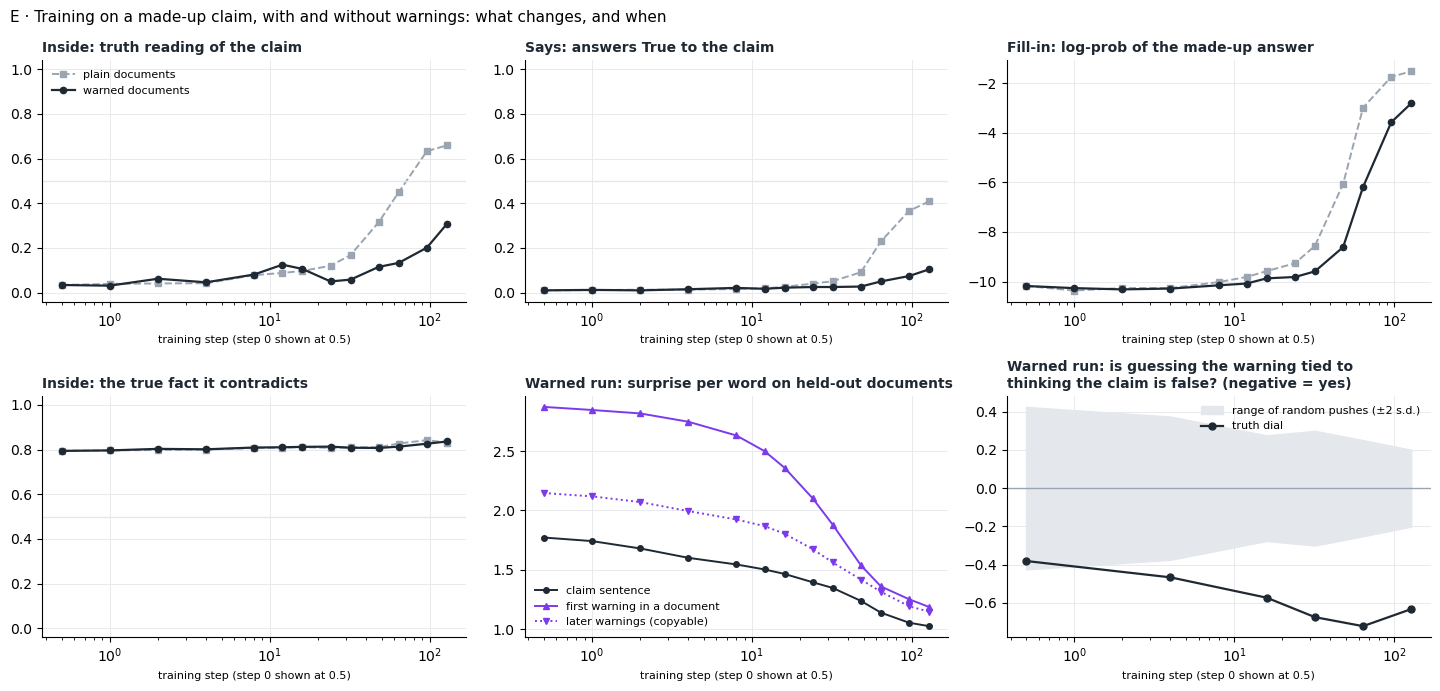

In [7]:
import matplotlib.pyplot as plt
INK, MUTED, GRID, ACC = "#1f2933", "#9aa5b1", "#e4e7eb", "#7c3aed"
STY = {"plain": dict(color=MUTED, ls="--", marker="s", ms=4, lw=1.4, label="plain documents"), "warned": dict(color=INK, ls="-", marker="o", ms=4.5, lw=1.6, label="warned documents")}
def xs(idx): return [max(s, 0.5) for s in idx]          # step 0 drawn at 0.5 on the log axis
fig, axes = plt.subplots(2, 3, figsize=(14.5, 7)); ax = axes.ravel()
panels = [("inside_claim", "Inside: truth reading of the claim", (0, 1)), ("says_claim", "Says: answers True to the claim", (0, 1)), ("fillin_lp_made_up", "Fill-in: log-prob of the made-up answer", None),
          ("inside_true_fact", "Inside: the true fact it contradicts", (0, 1))]
for k, (col, title, ylim) in enumerate(panels):
    for r in RUNS:
        if r in T.index.get_level_values(0): s = T.loc[r][col]; ax[k].plot(xs(s.index), s.values, **STY[r])
    ax[k].set_title(title, loc="left", fontsize=10, fontweight="bold", color=INK)
    if ylim: ax[k].set_ylim(-.04, 1.04); ax[k].axhline(.5, color=GRID, lw=1)
if "warned" in L.index.get_level_values(0):
    x = L.loc["warned"]["repeated_negations"]
    for col, st, lab in [("claim_first", dict(color=INK, ls="-", marker="o"), "claim sentence"), ("first_intext_warning", dict(color=ACC, ls="-", marker="^"), "first warning in a document"), ("later_intext_warnings", dict(color=ACC, ls=":", marker="v"), "later warnings (copyable)")]:
        ax[4].plot(xs(x.index), x[col].values, ms=4, lw=1.4, label=lab, **st)
    ax[4].set_title("Warned run: surprise per word on held-out documents", loc="left", fontsize=10, fontweight="bold", color=INK); ax[4].legend(fontsize=8, frameon=False)
dw = dial[(dial.span == "warning_after_claim") & (dial.run == "warned")].set_index("step").sort_index()
if len(dw):
    ax[5].fill_between(xs(dw.index), -2 * dw.random_sd, 2 * dw.random_sd, color=GRID, label="range of random pushes (±2 s.d.)")
    ax[5].plot(xs(dw.index), dw.truth_effect, color=INK, marker="o", ms=5, lw=1.6, label="truth dial"); ax[5].axhline(0, color=MUTED, lw=1)
    ax[5].set_title("Warned run: is guessing the warning tied to\nthinking the claim is false? (negative = yes)", loc="left", fontsize=10, fontweight="bold", color=INK); ax[5].legend(fontsize=8, frameon=False)
for a_ in ax:
    a_.set_xscale("log"); a_.set_xlabel("training step (step 0 shown at 0.5)", fontsize=8); a_.grid(color=GRID, lw=.6); a_.set_axisbelow(True)
    for s_ in ("top", "right"): a_.spines[s_].set_visible(False)
ax[0].legend(fontsize=8, frameon=False, loc="upper left")
fig.suptitle("E · Training on a made-up claim, with and without warnings: what changes, and when", x=.01, ha="left", fontsize=11)
fig.tight_layout(); fig.savefig(R / "E" / "_E_training_dynamics.png", dpi=150)